<div style="background:linear-gradient(135deg,#0a1230 0%,#141d44 55%,#1b1448 100%);border-radius:18px;padding:36px 32px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#00d4ff;font-weight:700;text-transform:uppercase">Part II · Describing Data &nbsp;|&nbsp; Chapter 12</div>
  <div style="font-size:40px;font-weight:900;line-height:1.1;margin:10px 0 6px">Standardization &amp; z-scores <span style="color:#00d4ff">🐍 Notebook</span></div>
  <div style="font-size:16px;color:#b9c2e0;max-width:720px;line-height:1.6">Five demos on the standard scale: turning any value into "standard deviations from the mean," proving standardizing keeps the shape, comparing across different scales, hunting outliers, and scaling features for machine learning without leaking data.</div>
  <div style="margin-top:18px;font-size:13px;color:#8892b0">Author: <b style="color:#e8eaf6">John Fisher</b> &nbsp;·&nbsp; Statistics, Data Science and AI: A Visual Handbook &nbsp;·&nbsp; 2026</div>
</div>

### 🎯 What you'll build in this notebook

| # | Demo | Idea it builds |
|---|------|----------------|
| 1 | The z-score, by hand | z = (x - mean) / sd, then mean 0 and sd 1 |
| 2 | Shape survives | standardizing re-scales, it does NOT make data normal |
| 3 | One common ruler | compare two exams on different scales; z to percentile |
| 4 | Spotting outliers | the \|z\| > 3 rule and why it can hide outliers |
| 5 | Scaling for ML | StandardScaler fit on train only, vs MinMaxScaler |

---

## ⚙️ Setup, imports & the book's plotting style

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(12)

NAVY="#0a1230"; INK="#1a2138"; INK_SOFT="#4a5578"
CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"; GREEN="#059669"; PINK="#db2777"; BLUE="#2563eb"; GRID="#e6e9f2"
plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
    "axes.edgecolor":GRID,"axes.linewidth":1.2,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,
    "axes.spines.top":False,"axes.spines.right":False,"axes.titlesize":13,"axes.titleweight":"bold","axes.titlecolor":INK,
    "axes.labelcolor":INK_SOFT,"axes.labelsize":11.5,"xtick.color":INK_SOFT,"ytick.color":INK_SOFT,"legend.frameon":False,
})
print("✅ Environment ready.")

✅ Environment ready.


<div style="background:#e0f7fb;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">DEMO 1 · THE Z-SCORE, BY HAND</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📏 How many SDs from the mean?</div>
<div style="color:#4a5578;margin-top:6px">A z-score strips away the original units and replaces them with one universal unit: standard deviations from the mean. The sign is direction, the size is distance.</div>
</div>

mean = 76.6,  sd = 11.5
score 85: z = (85 - 76.6) / 11.5 = +0.73  (+0.73 SDs above the mean)

Standardized set -> mean = 0.00, sd = 1.00
Every standardized dataset has mean 0 and sd 1, whatever the original units.


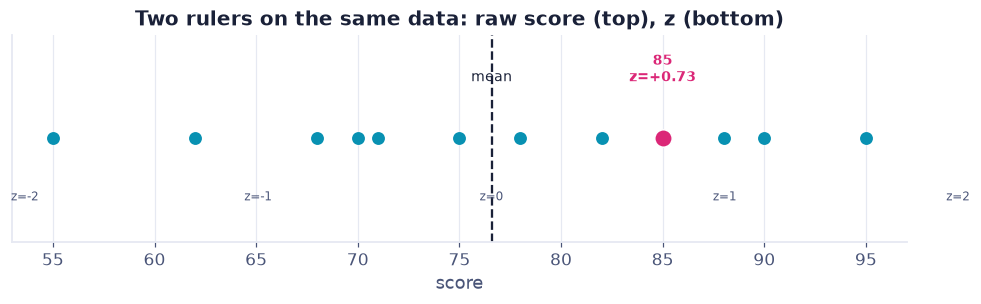

In [2]:
scores = pd.Series([55, 62, 68, 70, 71, 75, 78, 82, 85, 88, 90, 95])
mean, sd = scores.mean(), scores.std(ddof=0)        # population SD (ddof=0)
print(f"mean = {mean:.1f},  sd = {sd:.1f}")

# one value, by hand
x = 85
z = (x - mean) / sd
print(f"score {x}: z = ({x} - {mean:.1f}) / {sd:.1f} = {z:+.2f}  ({z:+.2f} SDs above the mean)")

# the whole series at once (scipy uses ddof=0 by default, matching above)
z_all = stats.zscore(scores)
print(f"\nStandardized set -> mean = {z_all.mean():.2f}, sd = {z_all.std():.2f}")
print("Every standardized dataset has mean 0 and sd 1, whatever the original units.")

# --- added visual ---
import matplotlib.pyplot as plt, numpy as np
_CY,_PU,_AM,_GR,_PK,_INK,_GRY,_BL = "#0891b2","#7c3aed","#d97706","#059669","#db2777","#1a2138","#c7ccda","#2563eb"
fig, ax = plt.subplots(figsize=(9, 2.9))
ax.scatter(scores.values, np.zeros(len(scores)), s=55, color=_CY, zorder=3)
ax.axvline(mean, color=_INK, lw=1.5, ls="--"); ax.text(mean, 0.55, "mean", ha="center", color=_INK, fontsize=9)
ax.scatter([85],[0], s=130, color=_PK, zorder=4, edgecolor="white")
ax.text(85, 0.55, f"85\nz={z:+.2f}", ha="center", color=_PK, fontweight="bold", fontsize=9)
for zz in [-2,-1,0,1,2]:
    ax.text(mean+zz*sd, -0.6, f"z={zz}", ha="center", color="#4a5578", fontsize=8)
ax.set_ylim(-1, 1); ax.set_yticks([]); ax.set_xlabel("score")
ax.set_title("Two rulers on the same data: raw score (top), z (bottom)")
plt.tight_layout(); plt.show()

<div style="background:#f0e9fe;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 2 · SHAPE SURVIVES</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🧬 Standardizing does NOT make data normal</div>
<div style="color:#4a5578;margin-top:6px">This is the big misconception. Standardizing is a linear transform: it shifts and rescales, so the silhouette, the skew, and the ordering all stay exactly the same. Only the axis numbers change.</div>
</div>

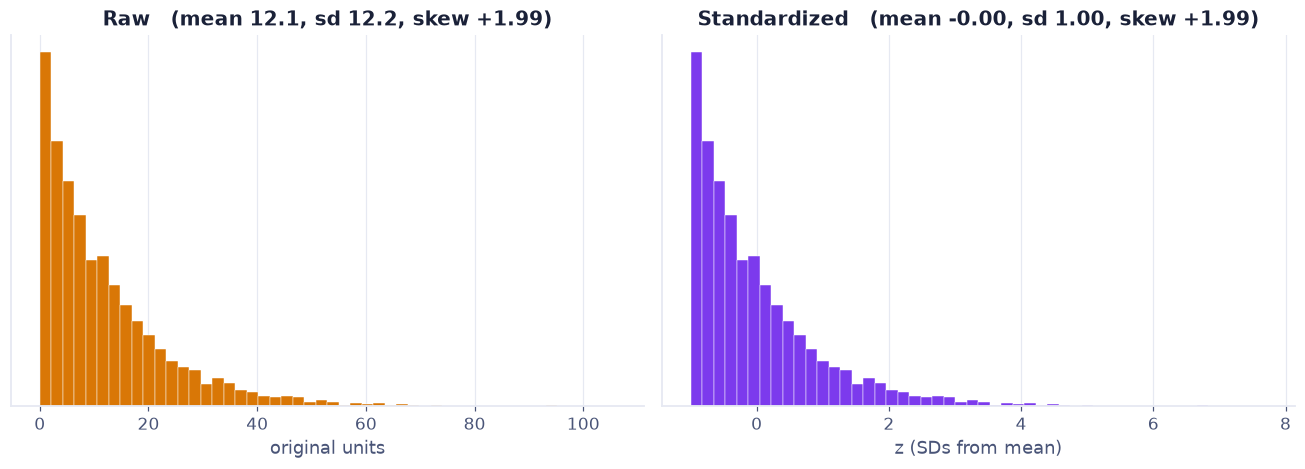

Same skew, same shape. Mean moved to 0 and sd to 1, but the distribution is just as skewed as before.


In [3]:
raw = rng.exponential(scale=12, size=4000)          # strongly right-skewed
z = stats.zscore(raw)

fig, (a1,a2) = plt.subplots(1, 2, figsize=(12, 4.4))
a1.hist(raw, bins=50, color=AMBER, edgecolor="white", linewidth=0.3)
a1.set_title(f"Raw   (mean {raw.mean():.1f}, sd {raw.std():.1f}, skew {stats.skew(raw):+.2f})")
a2.hist(z, bins=50, color=PURPLE, edgecolor="white", linewidth=0.3)
a2.set_title(f"Standardized   (mean {z.mean():.2f}, sd {z.std():.2f}, skew {stats.skew(z):+.2f})")
for ax in (a1,a2): ax.set_yticks([])
a1.set_xlabel("original units"); a2.set_xlabel("z (SDs from mean)")
plt.tight_layout(); plt.show()
print("Same skew, same shape. Mean moved to 0 and sd to 1, but the distribution is just as skewed as before.")

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">DEMO 3 · ONE COMMON RULER</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🧮 Comparing across different scales</div>
<div style="color:#4a5578;margin-top:6px">Raw scores from two different exams are not comparable. z-scores put them on the same ruler. And IF the data is roughly normal, a z maps to a percentile through the standard normal curve.</div>
</div>

Exam A: raw 84, z = +1.00  ->  ~84th percentile (if normal)
Exam B: raw 85, z = +1.50  ->  ~93th percentile (if normal)

Raw 85 > 84 suggests B, but z says you were further above average on Exam B (+1.5 vs +1.0 SD).
Empirical rule check: z within +/-1 ~ 68%, +/-2 ~ 95%, +/-3 ~ 99.7% of normal data.


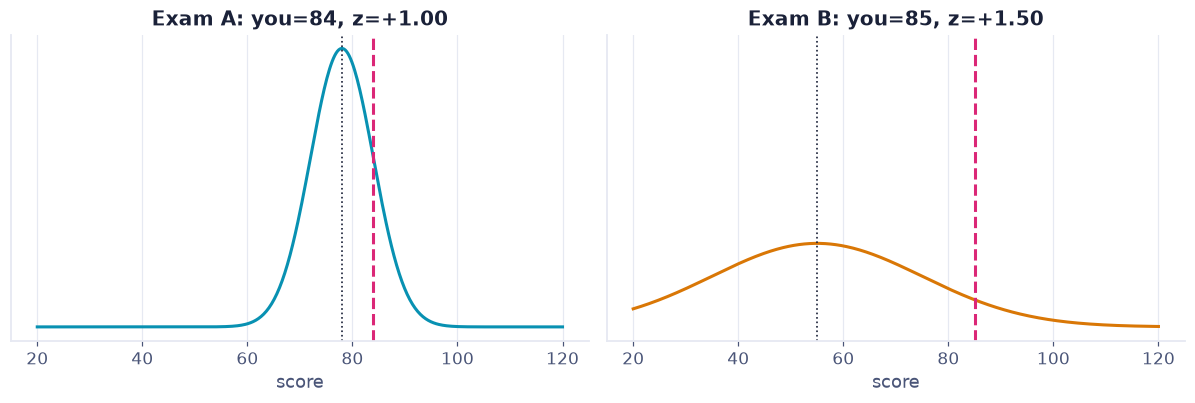

In [4]:
# You scored 84 on Exam A and 85 on Exam B. Which was the better performance?
examA = {"mean": 78, "sd": 6,  "you": 84}
examB = {"mean": 55, "sd": 20, "you": 85}
for name, e in [("Exam A", examA), ("Exam B", examB)]:
    z = (e["you"] - e["mean"]) / e["sd"]
    pct = stats.norm.cdf(z) * 100        # percentile IF scores are ~normal
    print(f"{name}: raw {e['you']}, z = {z:+.2f}  ->  ~{pct:.0f}th percentile (if normal)")

print("\nRaw 85 > 84 suggests B, but z says you were further above average on Exam B (+1.5 vs +1.0 SD).")
print("Empirical rule check: z within +/-1 ~ 68%, +/-2 ~ 95%, +/-3 ~ 99.7% of normal data.")

# --- added visual ---
import matplotlib.pyplot as plt, numpy as np
_CY,_PU,_AM,_GR,_PK,_INK,_GRY,_BL = "#0891b2","#7c3aed","#d97706","#059669","#db2777","#1a2138","#c7ccda","#2563eb"
xs = np.linspace(20, 120, 400)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, e, name, c in [(a1, examA, "Exam A", _CY), (a2, examB, "Exam B", _AM)]:
    ax.plot(xs, stats.norm.pdf(xs, e["mean"], e["sd"]), color=c, lw=2)
    zz = (e["you"]-e["mean"]) / e["sd"]
    ax.axvline(e["you"], color=_PK, lw=2, ls="--"); ax.axvline(e["mean"], color=_INK, lw=1.1, ls=":")
    ax.set_title(f"{name}: you={e['you']}, z={zz:+.2f}"); ax.set_yticks([]); ax.set_xlabel("score")
plt.tight_layout(); plt.show()

<div style="background:#e3f6ee;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">DEMO 4 · SPOTTING OUTLIERS</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🚨 The |z| > 3 rule, and where it fails</div>
<div style="color:#4a5578;margin-top:6px">A quick outlier test flags any |z| above 3. But the mean and SD are not robust: a few wild values inflate the SD and shrink everyone's z, hiding the very outliers you are hunting. A median/MAD modified z-score is sturdier.</div>
</div>

classic z-scores: [-0.41 -0.38 -0.35 -0.35 -0.32 -0.32 -0.3  -0.27 -0.24 -0.21  3.16]
flagged by |z|>3: [140]  (the outlier can mask itself: SD is inflated)

modified z (median/MAD): [-1.  -0.7 -0.3 -0.3  0.   0.   0.3  0.7  1.   1.3 42.2]
flagged by |mod z|>3.5: [140]  (robust test catches it clearly)


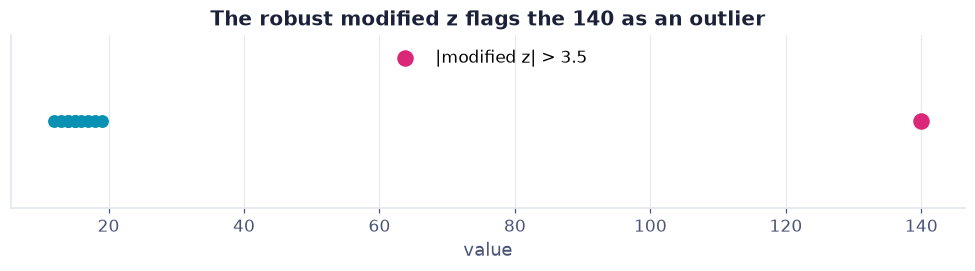

In [5]:
data = np.array([12, 13, 14, 14, 15, 15, 16, 17, 18, 19, 140])   # 140 is the outlier

z = (data - data.mean()) / data.std()
print("classic z-scores:", np.round(z, 2))
print("flagged by |z|>3:", data[np.abs(z) > 3], " (the outlier can mask itself: SD is inflated)")

# modified z-score: robust, uses median and MAD
med = np.median(data)
mad = np.median(np.abs(data - med))
mod_z = 0.6745 * (data - med) / mad
print("\nmodified z (median/MAD):", np.round(mod_z, 1))
print("flagged by |mod z|>3.5:", data[np.abs(mod_z) > 3.5], " (robust test catches it clearly)")

# --- added visual ---
import matplotlib.pyplot as plt, numpy as np
_CY,_PU,_AM,_GR,_PK,_INK,_GRY,_BL = "#0891b2","#7c3aed","#d97706","#059669","#db2777","#1a2138","#c7ccda","#2563eb"
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.scatter(data, np.zeros(len(data)), s=55, color=_CY, zorder=2)
out = data[np.abs(mod_z) > 3.5]
ax.scatter(out, np.zeros(len(out)), s=140, color=_PK, zorder=3, edgecolor="white", label="|modified z| > 3.5")
ax.set_yticks([]); ax.set_xlabel("value"); ax.legend(loc="upper center")
ax.set_title("The robust modified z flags the 140 as an outlier")
plt.tight_layout(); plt.show()

<div style="background:#e6effe;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">DEMO 5 · SCALING FOR MACHINE LEARNING</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🤖 Fit on train only, and pick your scaler</div>
<div style="color:#4a5578;margin-top:6px">Distance- and gradient-based models need features on a common scale. The rule that prevents data leakage: fit the scaler on the TRAINING data only, then apply it to the test data. StandardScaler gives mean 0 / sd 1; MinMaxScaler squeezes into [0,1] but is fragile to outliers.</div>
</div>

In [6]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

X = rng.normal(50, 15, size=(200, 1))
X_train, X_test = train_test_split(X, test_size=0.25, random_state=0)

scaler = StandardScaler().fit(X_train)        # learn mean & sd from TRAIN only
print(f"learned from train -> mean {scaler.mean_[0]:.2f}, sd {scaler.scale_[0]:.2f}")
Xtr = scaler.transform(X_train); Xte = scaler.transform(X_test)
print(f"train after scaling: mean {Xtr.mean():.2f}, sd {Xtr.std():.2f}")
print(f"test  after scaling: mean {Xte.mean():.2f}, sd {Xte.std():.2f}  (not exactly 0/1, and that is correct)")

# StandardScaler vs MinMaxScaler when one outlier sneaks in
feat = np.array([10, 12, 11, 13, 12, 14, 13, 500.0]).reshape(-1, 1)
std_ = StandardScaler().fit_transform(feat).ravel()
mm_  = MinMaxScaler().fit_transform(feat).ravel()
print("\nwith an outlier (500):")
print("  StandardScaler:", np.round(std_, 2))
print("  MinMaxScaler  :", np.round(mm_, 3), " <- the outlier pins max=1 and squashes the rest near 0")

learned from train -> mean 49.27, sd 14.33
train after scaling: mean 0.00, sd 1.00
test  after scaling: mean 0.20, sd 1.00  (not exactly 0/1, and that is correct)

with an outlier (500):
  StandardScaler: [-0.39 -0.38 -0.39 -0.37 -0.38 -0.37 -0.37  2.65]
  MinMaxScaler  : [0.    0.004 0.002 0.006 0.004 0.008 0.006 1.   ]  <- the outlier pins max=1 and squashes the rest near 0


## 🎓 Real-World Example: Comparing Scores Across Scales
Three exams, three different maximums (math out of 100, reading out of 40, science out of 200), so the raw scores cannot be compared directly. We **standardize** each column to a z-score, which lands every exam on one common scale (mean 0, SD 1), and then a student's strongest and weakest subjects become obvious. This is exactly what `StandardScaler` does before a model sees the data.

In [ ]:
# --- Real-World beat: standardize three exams onto one common scale ---
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    exam = pd.read_excel("../../data/ch12_exam_scales.xlsx", sheet_name="Data")
except FileNotFoundError: exam = pd.read_excel(BASE+"ch12_exam_scales.xlsx", sheet_name="Data")
cols = ["math_100", "reading_40", "science_200"]
z = (exam[cols] - exam[cols].mean()) / exam[cols].std()
print("raw means:", exam[cols].mean().round(1).to_dict())
print("raw SDs  :", exam[cols].std().round(1).to_dict())
print("after z-scoring -> mean", z.mean().round(2).abs().max(), "SD", z.std().round(2).min(), "(every exam now mean 0, SD 1)")
i = exam.science_200.idxmax()
print(f"\ntop-science student raw = {exam.loc[i, cols].to_dict()}")
print(f"                    z   = {z.loc[i].round(2).to_dict()}   (strong across all three, on one scale)")
fig, ax = plt.subplots(1, 2, figsize=(11,4))
labels = ["math\n/100", "reading\n/40", "science\n/200"]
ax[0].boxplot([exam[c] for c in cols], labels=labels, patch_artist=True, boxprops=dict(facecolor=AMBER, alpha=0.6))
ax[0].set_title("Raw scores: three different scales"); ax[0].set_ylabel("raw score")
ax[1].boxplot([z[c] for c in cols], labels=[l.split(chr(10))[0] for l in labels], patch_artist=True, boxprops=dict(facecolor=CYAN, alpha=0.6))
ax[1].axhline(0, color=INK_SOFT, ls="--", lw=1)
ax[1].set_title("After standardizing: one common scale (z)"); ax[1].set_ylabel("z-score")
plt.tight_layout(); plt.show()

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:24px 28px;font-family:Inter,sans-serif;box-shadow:0 8px 30px rgba(20,30,80,0.05)">
<div style="font-size:20px;font-weight:800;color:#1a2138">🎓 Recap</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:10px">
<li>A <b>z-score</b> = (x - mean) / sd: how many SDs a value sits from the mean. Sign = direction, size = distance.</li>
<li>Standardizing gives <b>mean 0 and sd 1</b> but <b>does not change the shape</b>: it is a linear transform.</li>
<li>z-scores put different scales on <b>one ruler</b>; if data is ~normal, z maps to a percentile via the standard normal curve.</li>
<li>The <b>|z| &gt; 3</b> outlier rule is handy but not robust; a <b>median/MAD modified z</b> resists masking.</li>
<li>For ML, scale features and <b>fit the scaler on training data only</b>; StandardScaler vs MinMaxScaler is a real choice.</li>
</ul>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:18px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>